<a href="https://colab.research.google.com/github/botastark/thesis/blob/main/ViTforAudioSpectogram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
%cd drive/MyDrive/Thesis/

/content/drive/MyDrive/Thesis


In [ ]:
import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F
import numpy as np

In [ ]:
!pip install -q -r /content/drive/MyDrive/Thesis/requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 15.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.0/469.0 KB 22.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 58.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 KB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 27.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 367.1/367.1 KB 19.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 352.1/352.1 KB 13.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.4/193.4 KB 10.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 33.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 KB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 39.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 KB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Transformer

In [ ]:
from Quaternion_Transformer_Pytorch.core_qnn.quaternion_ops import (
    hamilton_product,
    quaternion_conv,
    quaternion_transpose_conv,
    quaternion_linear,
)
from Quaternion_Transformer_Pytorch.core_qnn.quaternion_ops import (
    get_i,
    get_j,
    get_k,
    get_r,
)
from Quaternion_Transformer_Pytorch.core_qnn.quaternion_layers import (
    QuaternionLinearAutograd,
    QuaternionTransposeConv
)

In [ ]:
dtype = torch.FloatTensor
# dtype = torch.cuda.FloatTensor # Uncomment this to run on GPU

# N is batch size; D_in is input dimension;
# H is hidden dimension; D_out is output dimension.
N, D_in, H, D_out = 1, 4, 10, 4

# Create random Tensors to hold input and outputs, and wrap them in Variables.
# Setting requires_grad=False indicates that we do not need to compute gradients
# with respect to these Variables during the backward pass.
x = Variable(torch.randn(N, D_in).type(dtype), requires_grad=False)
y = Variable(torch.randn(N, D_out).type(dtype), requires_grad=False)
print(x.shape)
print(x.dim())
print(y.dim())
print(y.shape)
# Quaternion Feed-Forward
# Hamilton product for W weight matrix and Q quaternion
hamilton_product(x, y)


torch.Size([1, 4])
2
2
torch.Size([1, 4])


tensor([[-0.2247, -0.8351, -0.9607,  1.9667]])

In [ ]:
# Quaternion Attention
output_padding = 0
padding = 0


def ComponentSoftmax(q):
    scores_r, scores_i, scores_j, scores_k = get_r(q), get_i(q), get_j(q), get_k(q)

    # scores_r = scores_r.masked_fill(mask == 0, -1e9)
    scores_r = F.softmax(scores_r, dim=-1)
    # scores_i = scores_i.masked_fill(mask == 0, -1e9)
    scores_i = F.softmax(scores_i, dim=-1)
    # scores_j = scores_j.masked_fill(mask == 0, -1e9)
    scores_j = F.softmax(scores_j, dim=-1)
    # scores_k = scores_k.masked_fill(mask == 0, -1e9)
    scores_k = F.softmax(scores_k, dim=-1)

    scores = torch.cat([scores_r, scores_i, scores_j, scores_k], dim=-1)
    return scores




## Self Attention

In [ ]:
class self_attention(nn.Module):
    def __init__(self, embed_size, heads, k_dim = None, v_dim = None) -> None:
        super(self_attention, self).__init__()
        self.embed_size = embed_size
        self.heads = heads 
        self.head_dim = embed_size // heads # attention_head_size
        self.k_dim = k_dim if k_dim is not None else self.head_dim
        self.v_dim = v_dim if v_dim is not None else self.head_dim
   
        assert (
            self.head_dim * heads == embed_size
        ), "embed size must be divisible by heads"
        self.queries  = QuaternionLinearAutograd(self.head_dim, self.head_dim, bias=False)
        self.values   = QuaternionLinearAutograd(self.head_dim, self.v_dim, bias=False)
        self.keys     = QuaternionLinearAutograd(self.head_dim, self.k_dim, bias=False)
        

        # self.fc_out = QuaternionLinearAutograd(self.embed_size, embed_size)

    def forward(self, values, keys, query, mask):
        N = query.shape[0]
        value_len, key_len, query_len = values.shape[1], keys.shape[1], query.shape[1]
        values = values.reshape(N, value_len, self.heads, self.head_dim)
        keys = keys.reshape(N, key_len, self.heads, self.head_dim)
        queries = query.reshape(N, query_len, self.heads, self.head_dim)

        values = self.values(values)
        keys = self.keys(keys)
        queries = self.queries(queries)

        Q_quaternion = torch.chunk(queries, 4, dim=-1) # (B, L, H, E//4) of 4
        K_quaternion = torch.chunk(keys, 4, dim=-1) # (B, S, H, E//4) of 4

        # print("Q_quaternion shape", len(Q_quaternion))
        # print("Q_quaternion shape", Q_quaternion[0].shape)
        # print("K_quaternion shape", len(K_quaternion))
        # print("K_quaternion shape", K_quaternion[0].shape)
        # print("K_quaternion shape", K_quaternion.shape)
        # energy_r = (Q_quaternion[0], K_quaternion[0])
        energy_r = torch.einsum('bshd,bthd->bst', Q_quaternion[0], K_quaternion[0]) 
        energy_i = torch.einsum('bshd,bthd->bst', Q_quaternion[1], K_quaternion[1])
        energy_j = torch.einsum('bshd,bthd->bst', Q_quaternion[2], K_quaternion[2]) 
        energy_k = torch.einsum('bshd,bthd->bst', Q_quaternion[3], K_quaternion[3]) 

        energy = torch.stack((energy_r, energy_i, energy_j, energy_k), dim=-1)
      
        # if mask is not None:
        #     energy = energy.masked_fill(mask == 0, float("-1e20"))

        Qattention = energy / (self.embed_size ** (1 / 2))
        # print("Qattention shape", Qattention.shape)
        Qattention = torch.chunk(Qattention, 4, dim=-1) # (B, S, H, E//4) of 4
        energy_r = F.softmax(Qattention[0], dim=-1)
        energy_i = F.softmax(Qattention[1], dim=-1)
        energy_j = F.softmax(Qattention[2], dim=-1)
        energy_k = F.softmax(Qattention[3], dim=-1)

        # print("energy_r shape", energy_r.shape)
        
        # out = torch.einsum("nhql, nlhd->nqhd", [attention, values]).reshape(
        #     N, query_len, self.heads * self.head_dim
        # )
        # print(Qattention.shape)
        
        # Qattention = Qattention.reshape(N, query_len* self.heads* self.head_dim )
        # print("values shape", values.shape)
        V_quaternion = torch.chunk(values, 4, dim=-1) # (B, L, H, E//4) of 4
        # print("V_quaternion r shape", V_quaternion[0].shape)
        Attention_r = torch.einsum('bst,bthd->bshd', energy_r.squeeze(), V_quaternion[0])
        Attention_i = torch.einsum('bst,bthd->bshd', energy_i.squeeze(), V_quaternion[1])
        Attention_j = torch.einsum('bst,bthd->bshd', energy_j.squeeze(), V_quaternion[2])
        Attention_k = torch.einsum('bst,bthd->bshd', energy_k.squeeze(), V_quaternion[3])
        Qatt = torch.stack((Attention_r, Attention_i, Attention_j, Attention_k), dim=-1)
        # print("Attention_r shape", Attention_r.shape)
        # print("Qatt shape", Qatt.shape)
        # out = self.fc_out(Qatt)
        Qatt = Qatt.reshape(N, query_len, self.heads* self.head_dim)
        return Qatt

In [ ]:
class FeedForward(nn.Module):
    def __init__(self, embed_size, forward_expansion):
        super().__init__()
        # We set d_ff as a default to 2048
        self.linear_1 = QuaternionLinearAutograd(
            embed_size, forward_expansion * embed_size
        )
        # self.dropout = nn.Dropout(dropout)

        self.linear_2 = QuaternionLinearAutograd(
            forward_expansion * embed_size, embed_size
        )

    def forward(self, x):
        x = F.relu(self.linear_1(x))
        x = self.linear_2(x)
        return x

In [ ]:
def QNorm(x, eps):
    r, i, j, k = torch.chunk(x, chunks=4, dim=-1)
    qnorm = torch.sqrt(r * r + i * i + j * j + k * k + eps)
    r = r / qnorm
    i = i / qnorm
    j = j / qnorm
    k = k / qnorm

    return [r, i, j, k]


class Norm(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        super().__init__()

        self.size = d_model // 4
        # create two learnable parameters to calibrate normalisation
        self.alpha = nn.Parameter(torch.ones(self.size))
        self.bias = nn.Parameter(torch.zeros(self.size))
        self.eps = eps

    def forward(self, x):
        [r, i, j, k] = QNorm(x, self.eps)

        norm_r = self.alpha * r + self.bias
        norm_i = self.alpha * i + self.bias
        norm_j = self.alpha * j + self.bias
        norm_k = self.alpha * k + self.bias
        norm = torch.cat([norm_r, norm_i, norm_j, norm_k], dim=-1)

        return norm

## Transformer Block

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_size, heads, dropout, forward_expansion):
        super(TransformerBlock, self).__init__()
        self.attention = self_attention(embed_size, heads)
        self.norm1 = Norm(embed_size)
        self.norm2 = Norm(embed_size)
        self.feed_forward = FeedForward(embed_size, forward_expansion)
        self.dropout = nn.Dropout(dropout)

    def forward(self, value, key, query, mask):
        attention = self.attention(value, key, query, mask)
        x = self.dropout(self.norm1(attention + query))
        forward = self.feed_forward(x)
        out = self.dropout(self.norm2(forward + x))
        return out


class Encoder(nn.Module):
    def __init__(
        self,
        src_vocab_size,
        embed_size,
        num_layers,
        heads,
        device,
        forward_expansion,
        dropout,
        max_length,
    ):
        super(Encoder, self).__init__()
        self.embed_size = embed_size
        self.device = device

        self.word_embedding = nn.Embedding(src_vocab_size, embed_size)
        self.position_embedding = nn.Embedding(max_length, embed_size)
        # print("word_embedding shape", self.word_embedding)
        self.layers = nn.ModuleList(
            [
                TransformerBlock(
                    embed_size,
                    heads,
                    dropout=dropout,
                    forward_expansion=forward_expansion,
                )
                for _ in range(num_layers)
            ]
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        N, seq_length = x.shape
        positions = torch.arange(0, seq_length).expand(N, seq_length).to(self.device)

        x = x.long()
        out = self.dropout(self.word_embedding(x) + self.position_embedding(positions))
        for layer in self.layers:
            out = layer(out, out, out, mask)
        return out


class DecoderBlock(nn.Module):
    def __init__(self, embed_size, heads, forward_expansion, dropout, device):
        super(DecoderBlock, self).__init__()
        self.attention = self_attention(embed_size, heads)
        self.norm = Norm(embed_size)
        self.transformer_block = TransformerBlock(
            embed_size, heads, dropout, forward_expansion
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, value, key, src_mask, trg_mask):
        attention = self.attention(x, x, x, trg_mask)
        query = self.dropout(self.norm(attention + x))
        out = self.transformer_block(value, key, query, src_mask)
        return out


class Decoder(nn.Module):
    def __init__(
        self,
        trg_vocab_size,
        embed_size,
        num_layers,
        heads,
        forward_expansion,
        dropout,
        device,
        max_length,
    ):
        super(Decoder, self).__init__()
        self.embed_size = embed_size
        self.device = device
        self.word_embedding = nn.Embedding(trg_vocab_size, embed_size)
        self.position_embedding = nn.Embedding(max_length, embed_size)
        self.layers = nn.ModuleList(
            [
                DecoderBlock(embed_size, heads, forward_expansion, dropout, device)
                for _ in range(num_layers)
            ]
        )
        self.fc_out = QuaternionLinearAutograd(embed_size, trg_vocab_size)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask, trg_mask):
        N, seq_length = x.shape
        positions = torch.arange(0, seq_length).expand(N, seq_length).to(self.device)
        x = x.long()
        x = self.dropout(self.word_embedding(x) + self.position_embedding(positions))
        for layer in self.layers:
            x = layer(x, enc_out, enc_out, src_mask, trg_mask)
        out = self.fc_out(x)
        return out


class Transformer(nn.Module):
    def __init__(
        self,
        src_vocab_size,
        trg_vocab_size,
        src_pad_idx,
        trg_pad_idx,
        embed_size=256,
        num_layers=6,
        forward_expansion=4,
        heads=8,
        dropout=0,
        device="cuda",
        max_length=100,
    ):
        super(Transformer, self).__init__()
        self.encoder = Encoder(
            src_vocab_size,
            embed_size,
            num_layers,
            heads,
            device,
            forward_expansion,
            dropout,
            max_length,
        )
        self.decoder = Decoder(
            trg_vocab_size,
            embed_size,
            num_layers,
            heads,
            forward_expansion,
            dropout,
            device,
            max_length,
        )
        self.src_pad_idx = src_pad_idx
        self.trg_pad_idx = trg_pad_idx
        self.device = device

    def make_src_mask(self, src):
        src_mask = (src != self.src_pad_idx).unsqueeze(1).unsqueeze(2)
        # (N,1,1,src_len)
        return src_mask.to(self.device)

    def make_trg_mask(self, trg):
        N, trg_len = trg.shape
        trg_mask = torch.tril(torch.ones((trg_len, trg_len))).expand(
            N, 1, trg_len, trg_len
        )
        return trg_mask.to(self.device)

    def forward(self, src, trg):
        src_mask = self.make_src_mask(src)
        trg_mask = self.make_trg_mask(trg)
        enc_src = self.encoder(src, src_mask)
        out = self.decoder(trg, enc_src, src_mask, trg_mask)
        return out


if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    x = torch.Tensor([[1, 5, 6, 4, 3, 9, 5, 2], [1, 8, 7, 3, 4, 5, 6, 7]]).to(device)
    trg = torch.Tensor([[1, 7, 4, 3, 5, 9, 2], [1, 5, 6, 2, 4, 7, 6]]).to(device)
    src_pad_idx = 0
    trg_pad_idx = 0
    src_vocab_size = 10
    trg_vocab_size = 10
    model = Transformer(
        src_vocab_size, trg_vocab_size, src_pad_idx, trg_pad_idx, device=device
    ).to(device)
    print(x.shape)
    print()
    out = model(x, trg[:, :-1])
    # print(out.shape)
    # print(out)

torch.Size([2, 8])



In [ ]:
 !pip install -q -r /Users/botuser/Desktop/thesis/tf_version/requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: '/Users/botuser/Desktop/thesis/tf_version/requirements.txt'


# Dataset

In [ ]:
from datasets import load_dataset
import numpy as np
import librosa
from datasets import Array2D
import librosa.display
import matplotlib.pyplot as plt
# https://github.com/sankalp2610/Speech_Command_Recognition
# https://huggingface.co/datasets/speech_commands
# https://huggingface.co/docs/datasets/v2.9.0/en/package_reference/loading_methods#datasets.load_dataset

In [ ]:
from torch.utils.data import DataLoader
# import transformers
batch_size = 64
embedding_dim = 32
patch_size = 8
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from einops.layers.torch import Rearrange


In [ ]:
def preprocess(ex):
    # The conversion to a dB scale is useful to normalize the frequency values
    # (try to plot the spectrogram ignoring the normalization and see the results
    # for yourself!).
    ex["spec"] = (
        librosa.power_to_db(
            librosa.feature.melspectrogram(
                y=ex["audio"]["array"], sr=16_000, win_length=1500
            ),
            ref=np.max,
            top_db=80,
        )
        / 80.0
        + 1.0
    )
    return ex

In [ ]:
def data_prep(split='train'):
  # https://huggingface.co/datasets/speech_commands
  data = load_dataset("speech_commands", "v0.01", split=split)
  data_processed = data.filter(lambda ex: not ex["is_unknown"])
  data_processed = data_processed.filter(
    lambda ex: ex["audio"]["array"].shape[0] == 16_000
  )
  data_final = data_processed.map(
    preprocess, remove_columns=["file", "audio", "speaker_id", "utterance_id"]
  )
  features = data_final.features.copy()

  features["spec"] = Array2D(
      (128, 32), "float64"
  )  # Note: 128 frequencies, 32 windows with the current configuration

  data_final = data_final.cast(features)
  if split == 'test':
    data_final.set_format('numpy')
    # trail_sample
    print(type(data_final[0]['spec']))
    librosa.display.specshow(data_final[0]['spec'])
  ds_torch = data_final.with_format("torch", device=device, columns=["spec", "label"])
  # batch_size = 64
  dataloader = DataLoader(ds_torch, batch_size=batch_size)
  return dataloader



In [ ]:
train_dataloader = data_prep(split = 'train')
dev_dataloader =  data_prep(split='validation')



Generating train split:   0%|          | 0/51093 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6799 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3081 [00:00<?, ? examples/s]

Dataset speech_commands downloaded and prepared to /root/.cache/huggingface/datasets/speech_commands/v0.01/0.1.0/ba3d9a6cf49aa1313c51abe16b59203451482ccb9fee6d23c94fecabf3e206da. Subsequent calls will reuse this data.


Filter:   0%|          | 0/51093 [00:00<?, ? examples/s]

...

Casting the dataset:   0%|          | 0/16624 [00:00<?, ? examples/s]

Filter:   0%|          | 0/6799 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2578 [00:00<?, ? examples/s]

Map:   0%|          | 0/2325 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/2325 [00:00<?, ? examples/s]

In [ ]:

# librosa.display.waveshow(data[1]["audio"]["array"], sr=16_000)

In [ ]:
for x in train_dataloader:
    xb = x["spec"]
    yb = x["label"]
    print(xb.shape)
    print(yb)

    break

torch.Size([64, 128, 32])
tensor([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3])


In [ ]:
patchifier = Rearrange('b (h p1) (w p2) -> b (h w) (p1 p2)', p1=patch_size, p2=patch_size)

In [ ]:
y = patchifier(xb[0:5])

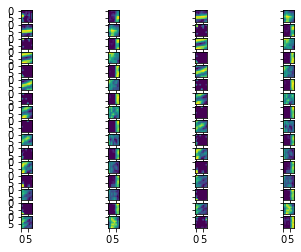

In [ ]:
# Let's try plotting all the patches
n_patches_h, n_patches_w = xb.shape[1] // patch_size, xb.shape[2] // patch_size
f, axs = plt.subplots(n_patches_h, n_patches_w, sharex=True, sharey=True)
for i in range(n_patches_h):
  for j in range(n_patches_w):
    patch = y[0, 2*i + j, :].numpy().reshape(patch_size, patch_size)
    axs[i, j].imshow(patch)

In [ ]:
# num_patches = (xb.shape[1] // patch_size) * (xb.shape[2] // patch_size)

In [ ]:
class InputEmbedding(nn.Module):
    def __init__(self, patch_size=8, embedding_dim=32):
        super().__init__()
        self.patchifier = Rearrange(
            "b (h p1) (w p2) -> b (h w) (p1 p2)", p1=patch_size, p2=patch_size
        )
        self.patch_size = patch_size
        self.embedding_dim = embedding_dim
        self.proj = nn.Linear(64, embedding_dim)
        num_patches = 64
        # # Matrix of positional embeddings (it would be better to initialize them with a TF initializer)
        norm_distr_pos = torch.normal(mean = 0, std=0.01, size = (1, num_patches + 1, self.embedding_dim))
        self.pos_embeddings = nn.Parameter(norm_distr_pos, requires_grad=True)
        # # Class token
        norm_distr_cls = torch.normal(mean = 0,std=0.01, size = (1, 1, self.embedding_dim))
        # self.cls_token = torch.normal(mean = torch.Tensor(1, 1, self.embedding_dim), std=0.01)
        self.cls_token = nn.Parameter(norm_distr_cls, requires_grad=True)

    def forward(self, x):
        # Build the patches and linearly project them
        x = self.proj(
            self.patchifier(x)     )  # Output shape: (b, num_patches, embedding_dim)
        # Add the class token
        cls_token = self.cls_token.detach().numpy()
        cls_token = torch.tensor(np.repeat(cls_token, x.shape[0], 0))

        x = torch.cat(
            [cls_token, x], axis=1
        )  # Output shape: (b, num_patches + 1, embedding_dim)
        # Sum the positional embeddings
        return x  #+ self.pos_embeddings

In [ ]:
inp_embedding = InputEmbedding()
y = inp_embedding(xb[0:5])
# print(y)

# Vision Transformer

In [ ]:
import os
from tqdm import tqdm
import torch.nn.functional as F



In [ ]:
class VisionTransformer(nn.Module):
  # The final ViT model is given by the input embedding, multiple transformer blocks,
  # and a final classification head applied on the class token embedding.
  def __init__(self, heads, embedding_dim):
    super().__init__()
    self.inp_embedding = InputEmbedding()
    self.block1 = TransformerBlock(
                    embed_size = embedding_dim,
                    heads = heads,
                    dropout = 0.2,
                    forward_expansion=1,
                )
    self.block2 = TransformerBlock(
                    embed_size = embedding_dim,
                    heads = heads,
                    dropout = 0.2,
                    forward_expansion=1,
    )
    self.block3 = TransformerBlock(
                    embed_size = embedding_dim,
                    heads = heads,
                    dropout = 0.1,
                    forward_expansion=1,
    )
    self.number_labels = 10
    self.classifier = nn.Linear(embedding_dim, self.number_labels)
    self.GELU = nn.GELU()

  def compute_loss(
        self, logits: torch.Tensor, labels: torch.Tensor
    ) -> torch.Tensor:
        """
        Compute the loss of the model.
        Args:
            logits (`torch.Tensor`):
                The logits of the model.
            labels (`torch.Tensor`):
                The labels of the model.
        Returns:
            obj:`torch.Tensor`: The loss of the model.
        """

        return F.cross_entropy(
            logits.view(-1, self.number_labels),
            labels.view(-1),
            ignore_index=-100,
            )

  def forward(
      self,
      input: torch.Tensor = None, 
      mask: torch.Tensor = None,
      compute_predictions: bool = False,
      compute_loss: bool = True,
      ):

    labels = input['label']
    x = input['spec']
    x = self.inp_embedding(x)             # (b, num_patches + 1, embedding_dim)
    
    x = self.block1(x, x, x, mask)
    x = self.block2(x, x, x, mask)
    x = self.block3(x, x, x, mask)
    # print(x.shape)

    # x = self.block2(x, training=training)
    # x = self.block3(x, training=training)

    classifier_output = self.classifier(x[:, 0, :])
    logits = self.GELU(classifier_output)
    output = {"logits": logits}
    # # print()
    if compute_predictions:
        predictions = logits.argmax(dim=-1)
        output["predictions"] = predictions

    if compute_loss and labels is not None:
        output["loss"] = self.compute_loss(logits, labels)
    return output

## test

<class 'numpy.ndarray'>
tensor([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3])
tensor([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3])
tensor([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3])
tensor([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 9, 9, 9])
tensor([9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9,
        9, 9, 9, 9, 9, 9, 9,

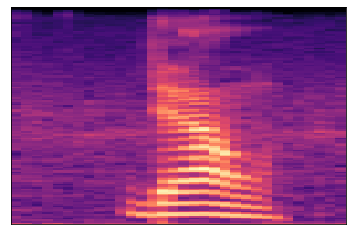

In [ ]:
# train_dataloader = data_prep(split = 'train')
# dev_dataloader =  data_prep(split='validation')
test_dataloader =  data_prep(split='test')
for n in test_dataloader:
  for k, v in n.items():
    if k == 'label':

      print(v)
    # print(k)

    
    
# break

In [ ]:
vit = VisionTransformer(heads = 4, embedding_dim = 32)
vit.to(device)
# for n in train_dataloader:
#   batch = {k: v.to(device) for k, v in n.items()}
#   # mask = make_src_mask(batch)
#   outputs = vit(batch, mask=None)
  # break

VisionTransformer(
  (inp_embedding): InputEmbedding(
    (patchifier): Rearrange('b (h p1) (w p2) -> b (h w) (p1 p2)', p1=8, p2=8)
    (proj): Linear(in_features=64, out_features=32, bias=True)
  )
  (block1): TransformerBlock(
    (attention): self_attention(
      (queries): QuaternionLinearAutograd(in_features=2, out_features=2, bias=False, init_criterion=glorot, weight_init=quaternion, rotation=False, seed=661)
      (values): QuaternionLinearAutograd(in_features=2, out_features=2, bias=False, init_criterion=glorot, weight_init=quaternion, rotation=False, seed=127)
      (keys): QuaternionLinearAutograd(in_features=2, out_features=2, bias=False, init_criterion=glorot, weight_init=quaternion, rotation=False, seed=826)
    )
    (norm1): Norm()
    (norm2): Norm()
    (feed_forward): FeedForward(
      (linear_1): QuaternionLinearAutograd(in_features=8, out_features=8, bias=True, init_criterion=glorot, weight_init=quaternion, rotation=False, seed=129)
      (linear_2): QuaternionLin

In [ ]:

num_workers = 2
# optim
learning_rate = 1e-3
weight_decay = 0.01
transformer_learning_rate = 5e-6
transformer_weight_decay = 0.001
# training
epochs = 5

from torch.optim import Adam
groups = [
  {
    "params": vit.block3.parameters(),
    "lr": transformer_learning_rate,
    "weight_decay": transformer_weight_decay,
  },
  {
    "params": vit.block2.parameters(),
    "lr": transformer_learning_rate,
    "weight_decay": transformer_weight_decay,
  },
  {
    "params": vit.classifier.parameters(),
    "lr": learning_rate,
    "weight_decay": weight_decay,
  },
  {
    "params": vit.block1.parameters(),
    "lr": transformer_learning_rate,
    "weight_decay": transformer_weight_decay,
  },
]
optimizer = Adam(groups)

In [ ]:

def train(device, model: torch.nn.Module, epochs: int, optimizer: torch.optim.Optimizer):
    epoch_loss = list()
    val_epoch_loss = list()

    # project_folder = '/content/nlp2022-hw3'
    # state_dict_path = os.path.join( project_folder, 'model' )

    early_stopping = True
    early_stopping_mode = 'loss'
    early_stopping_patience = 2
    patience_counter = 0


    number_of_training_steps = len([b for b in train_dataloader])
    for epoch in range(epochs):  # loop over the dataset multiple times
      batch_pbar = tqdm(enumerate(train_dataloader), total=number_of_training_steps)
      losses = []
      for i, batch in batch_pbar:
        # zero the parameter gradients
        optimizer.zero_grad()
        # forward + backward + optimize
        # move batch data to the specified device
        batch = {k: v.to(device) for k, v in batch.items()}
        # ** operator converts batch items in named arguments, (e.g. 'input_ids', 'attention_mask_ids' ...), taken as input by the model forward pass
        outputs = model(batch)
        loss = outputs["loss"]
        loss.backward()
        optimizer.step()
        batch_pbar.set_postfix({'loss': loss.item()})
        losses.append(loss.item())
      epoch_loss.append(torch.mean(torch.tensor(losses)))
      print('loss {:.3f} \n'.format( epoch_loss[-1]))
      # torch.save(model.state_dict(),
      #        os.path.join(state_dict_path, 'state_{}.pt'.format(epoch)))


      number_of_validation_steps = len([b for b in dev_dataloader])
      eval_pbar = tqdm(enumerate(dev_dataloader), total=number_of_validation_steps)
      val_losses = []
      for i, batch in eval_pbar:
          with torch.no_grad():
              batch = {k: v.to(device) for k, v in batch.items()}
              # ** operator converts batch items in named arguments, (e.g. 'input_ids', 'attention_mask_ids' ...), taken as input by the model forward pass
              outputs = model(batch)
              val_loss = outputs["loss"]
              batch_pbar.set_postfix({'loss': loss.item()})
              val_losses.append(val_loss.item())
      val_epoch_loss.append(torch.mean(torch.tensor(val_losses)))
      print('val loss {:.3f} \n'.format( val_epoch_loss[-1]))
      # to  stop training before overfitting
      if early_stopping:
          # choose metric to monitor
          stop = early_stopping_mode == 'loss' and epoch > 0 and val_epoch_loss[-1] >= val_epoch_loss[-2]
          # set patience
          if stop:
              if patience_counter >= early_stopping_patience:
                  # print('Early stop.')
                  break
              else:
                  patience_counter += 1
                  print(f'-- Patience {patience_counter} out of {early_stopping_patience}.\n')
    return epoch_loss, val_epoch_loss
    

In [ ]:
torch.cuda.empty_cache()

In [ ]:
epoch_loss = train(device, vit, epochs = epochs, optimizer = optimizer)

100%|██████████| 260/260 [02:53<00:00,  1.50it/s, loss=1.98]


loss 2.455 



100%|██████████| 37/37 [00:12<00:00,  2.88it/s]


val loss 2.313 



100%|██████████| 260/260 [02:54<00:00,  1.49it/s, loss=2.18]


...

val loss 2.301 



100%|██████████| 260/260 [02:53<00:00,  1.50it/s, loss=2.29]


loss 2.309 



100%|██████████| 37/37 [00:13<00:00,  2.75it/s]

val loss 2.301 

-- Patience 1 out of 2.

